#  CustomerPulse: Retention Intelligence System

This project focuses on predicting customer churn using Machine Learning and helping businesses identify customers who are likely to leave their services.

# Problem Statement

Many businesses lose customers because they cannot identify
which customers are likely to leave.

This project uses Machine Learning to predict customer churn
based on customer data.

The goal is to help businesses understand customer behavior
and improve customer retention.

# Business Objective

The main goal is to:

Predict whether a customer will churn or not.<br>
Identify factors influencing churn.<br>
Provide business recommendations to reduce customer loss.<br>
Improve customer retention and revenue.<br>

## Project workflow -
```
Data Collection
       ↓
Data Cleaning
       ↓
Exploratory Data Analysis
       ↓
Feature Selection
       ↓
Data Preprocessing
       ↓
Model Training
       ↓
Model Evaluation
       ↓
Business Insights
```

## Import Libraries


In [5]:
# Data Handling (load, clean, manipulate  &  array and mathematical oprs)
import pandas as pd
import numpy as np

# Visualization ( charts, graphs, heatmaps)
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    
)



## Load Dataset

In [6]:
df =pd.read_csv("C:/Users/iamhe/OneDrive/Documents/Desktop/customer_churn_dataset.csv")
# verify data loaded correctly
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Initial Inspection 

helps understand: Dataset size, Data types, Missing values, Numerical and categorical features

In [21]:
# Number of rows and columns
print("shape:", df.shape)


shape: (10000, 12)


In [4]:
# checks the data types of all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


# Data Preparation

In [7]:
# Fill missing values --> median imputation - robust against outliers

df.fillna(df.median(numeric_only=True), inplace=True)

In [9]:
# Remove unnecessary columns
# --> Customer ID has no predictive value.
# -->It only uniquely identifies customers.
# -->Removing it improves model performance.

if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Exploratory Data Analysis (Visualization)
It helps identify patterns, trends, relationships, missing values, outliers, and data quality issues.

### 1. Customers with Higher Balance Showed Higher Churn


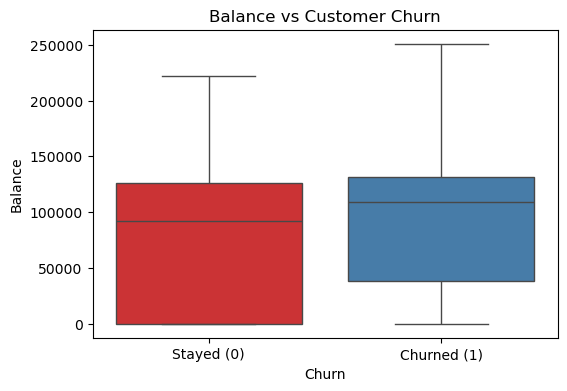

In [7]:
plt.figure(figsize=(6,4))
# detect outlier and numerical distribution
sns.boxplot(
    data=df,
    x='churn',
    y='balance',
    palette='Set1'
)

plt.title('Balance vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Balance')

plt.xticks([0,1], ['Stayed (0)', 'Churned (1)'])

plt.show()


**Insight**
- This suggests premium customers are more likely to leave.

**Suggestion**
- Loyalty rewards
- Premium customer programs
- Personalized offers
---

### 2. Older Customers Had Higher Churn Rate

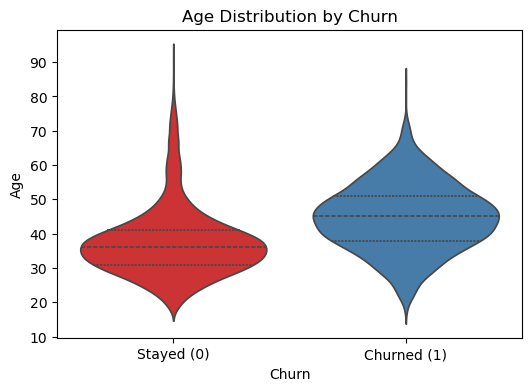

In [9]:
plt.figure(figsize=(6,4))
# show spreadness and density
sns.violinplot(
    data=df,
    x='churn',
    y='age',
    inner='quart',
    palette='Set1'
)
plt.title('Age Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Age')

plt.xticks([0,1], ['Stayed (0)', 'Churned (1)'])

plt.show()

**Insight**
- Age has a strong influence on customer churn behavior.

**Suggestion**
- Better customer support
- Dedicated relationship managers
- Personalized communication
---

### 3. Active Members Were Less Likely to Churn

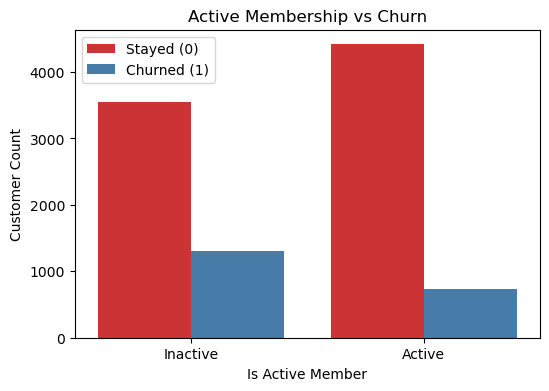

In [10]:
plt.figure(figsize=(6,4))
# Compare, category-wise distributions
sns.countplot(
    data=df,
    x='active_member',
    hue='churn',
    palette='Set1'
)
plt.title('Active Membership vs Churn')
plt.xlabel('Is Active Member')
plt.ylabel('Customer Count')

plt.xticks([0,1], ['Inactive', 'Active'])

plt.legend(['Stayed (0)', 'Churned (1)'])
plt.show()

**Insight**
- Customer engagement strongly impacts retention.

**Suggestion**
- Engagement campaigns
- Reward programs
- Regular customer interaction
---

## Split Features & Target

In [22]:
X = df.drop('churn', axis=1)        # Features
y = df['churn']                     # Target

## Identify Numerical and Categorical Columns

Machine learning algorithms process numerical and categorical data differently. Numerical data requires scaling, while categorical data requires encoding.

In [29]:
# Get numerical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Get categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Show numerical columns
print("Numerical Columns:")
print(list(numerical_cols))

# Show categorical columns
print("\nCategorical Columns:")
print(list(categorical_cols))


Numerical Columns:
['customer_id', 'credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']

Categorical Columns:
['country', 'gender']


## Preprocessing Pipeline

Pipeline allows sequentially apply a list of transformers to preprocess the data.

Used to ensure that these transformations are applied consistently to both my training and testing sets, which prevents data leakage.

In [31]:
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])                                                              # standarize numerical features (mean = 0 , SD = 1)

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder())
])                                                              # convert categorical features in numerical format

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])                                                              # apply separate transformers for numerical and categorical data



## Train Test Split

This prevents biased evaluation and ensures fair testing.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


## Machine Learning Models

In [35]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}


## Cross Validation

--> it checks a model's reliability by testing it multiple times on different data splits.

In [37]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc'
    )

    results[name] = scores

    print(f"{name} ROC-AUC: {scores.mean():.4f}")

Logistic Regression ROC-AUC: 0.7628
Random Forest ROC-AUC: 0.8493
Gradient Boosting ROC-AUC: 0.8611


## Compare Models

--> ROC-AUC measures model classification performance (0.5 - poor to 1.0 - Perfect)

In [41]:
comparison = pd.DataFrame({
    'Model': results.keys(),
    'ROC_AUC': [results[m].mean() for m in results]
})

comparison.sort_values(by='ROC_AUC', ascending=False)

,Model,ROC_AUC
2,Gradient Boosting,0.861106
1,Random Forest,0.849311
0,Logistic Regression,0.762849


## Select Best Model

--> Gradient Boosting achieved the highest ROC-AUC score which means it can better identify customers likely to churn.

In [42]:
best_model_name = max(results, key=lambda x: results[x].mean())

print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: Gradient Boosting


## Final Pipeline Training

In [45]:
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Prediction

In [46]:
y_pred = final_pipeline.predict(X_test)
y_prob = final_pipeline.predict_proba(X_test)[:,1]


## Evaluation Metrics

In [49]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)


print("Precision:", round(precision,4))         # Measures how many predicted churn customers actually churned.
print("Recall:", round(recall,4))               # Measures how many actual churn customers were identified.
print("F1 Score:", round(f1,4))                 # Balances precision and recall.
print("ROC AUC:", round(roc_auc,4))             # Measures classification capability across thresholds.

Precision: 0.7778
Recall: 0.4988
F1 Score: 0.6078
ROC AUC: 0.8697


## Feature Importance

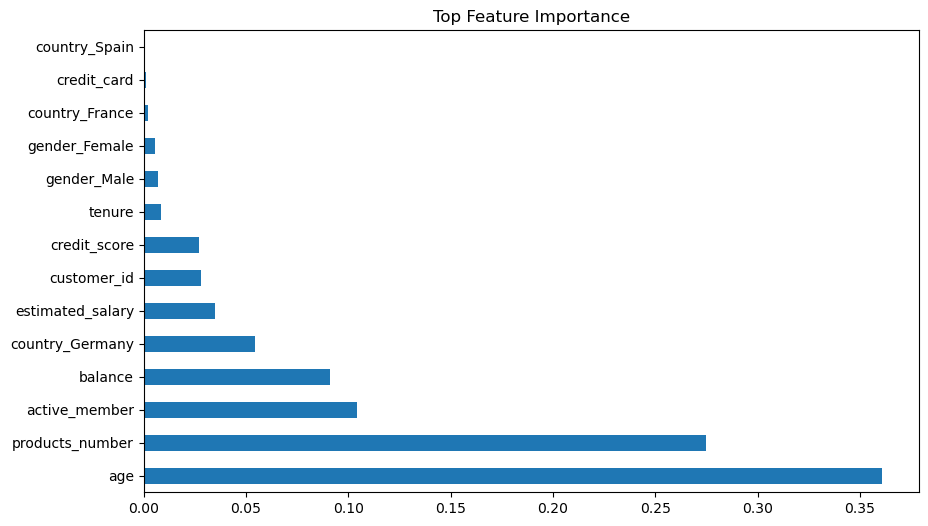

In [25]:
if hasattr(best_model, 'feature_importances_'):

    encoded_features = list(
        final_pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(categorical_cols)
    )

    feature_names = list(numerical_cols) + encoded_features

    importance = pd.Series(
        best_model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(10,6))
    importance.plot(kind='barh')
    plt.title('Top Feature Importance')
    plt.show()

## KEY BUSINESS INSIGHTS

1. High-balance customers are more likely to churn.
2. Older customers show higher churn behavior.
3. Active customers are less likely to leave.
4. Customers using fewer services were more likely to churn.
5. Customer engagement strongly affected retention.
---

## RECOMMENDATIONS
- Provide loyalty rewards to high value customers
- Improve customer engagement
- Offer personalized customer support for senior customers
- Improve Customer Retention Programs
---

## FUTURE SCOPE
1. Integrating real-time customer transaction data.
2. Improving accuracy using hyperparameter tuning and using advanced ML algorithms.
3. Using cloud deployment for large-scale business usage.
4. Integrate customer interaction data from emails and call logs using natural language processing to enhance prediction accuracy.

## Gradio Dashboard

https://2d3b193fe106c13266.gradio.live